In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Model comparison results
data = {
    "Model": [
        "CNN",
        "VGG16",
        "ResNet50",
        "MobileNet",
        "InceptionV3",
        "EfficientNetB0"
    ],

    "Accuracy": [
        0.98,
        0.72,
        0.74,
        0.69,
        0.75,
        0.18
    ],

    "Precision": [
        0.98,
        0.71,
        0.73,
        0.68,
        0.74,
        0.17
    ],

    "Recall": [
        0.98,
        0.70,
        0.72,
        0.67,
        0.73,
        0.17
    ],

    "F1 Score": [
        0.98,
        0.70,
        0.72,
        0.67,
        0.73,
        0.17
    ]
}

df = pd.DataFrame(data)

df

,Model,Accuracy,Precision,Recall,F1 Score
0,CNN,0.98,0.98,0.98,0.98
1,VGG16,0.72,0.71,0.70,0.70
2,ResNet50,0.74,0.73,0.72,0.72
3,MobileNet,0.69,0.68,0.67,0.67
4,InceptionV3,0.75,0.74,0.73,0.73
5,EfficientNetB0,0.18,0.17,0.17,0.17


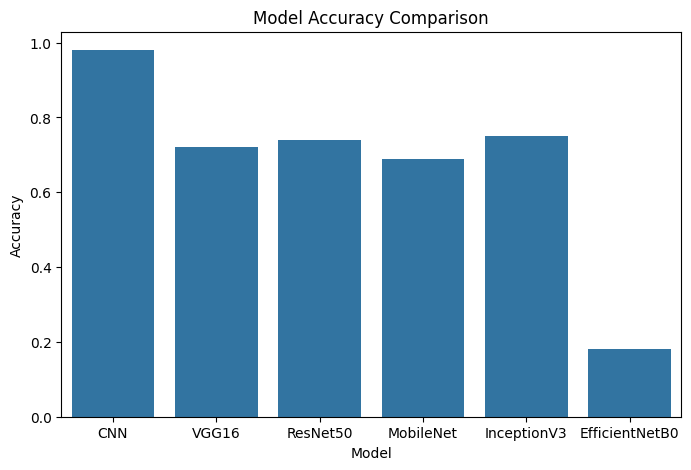

In [3]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=df
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.show()

Found 3187 images belonging to 11 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 39s 385ms/step


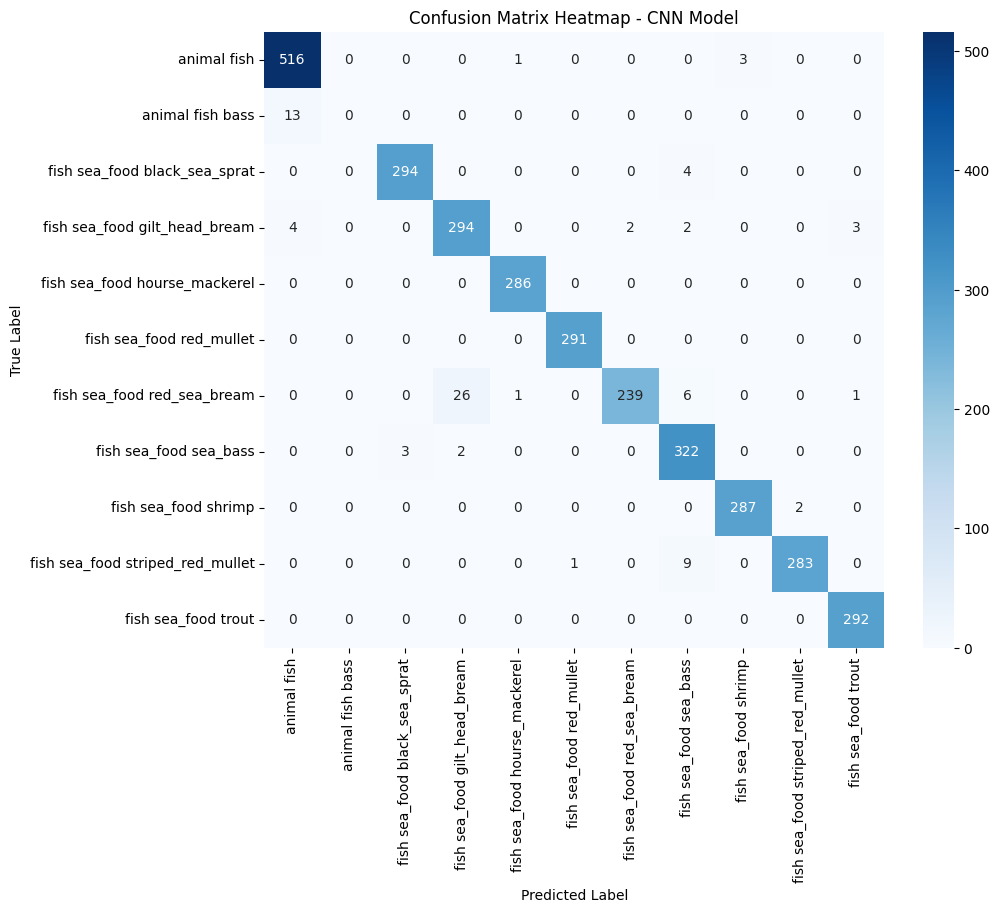

In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dataset path
data_path = "Dataset/images.cv_jzk6llhf18tm3k0kyttxz/data"

# Test data generator
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    data_path + "/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Load best model (CNN)
model = tf.keras.models.load_model("models/cnn_model.keras")

# Predictions
predictions = model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_generator.class_indices.keys(),
    yticklabels=test_generator.class_indices.keys()
)

plt.title("Confusion Matrix Heatmap - CNN Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [5]:
best_model = df.loc[df["Accuracy"].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model         CNN
Accuracy     0.98
Precision    0.98
Recall       0.98
F1 Score     0.98
Name: 0, dtype: object
